In [ ]:
!pip install pyspark --quiet
print('pyspark installation complete')

pyspark installation complete


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark = SparkSession.builder \
    .appName('Day4_bd_sales') \
    .config('spark.sql.adaptive.enables','true') \
    .getOrCreate()
print(f'spark version : {spark.version}')
print(f'SparkSession : ACTIVE')
print(f'application name:{spark.conf.get("spark.app.name")}')


spark version : 4.0.2
SparkSession : ACTIVE
application name:Day4_bd_sales


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving large_sales_data.csv to large_sales_data (2).csv


In [ ]:
df_bronze = spark.read \
   .option('header', 'true') \
   .option('inferSchema', 'true') \
   .csv('large_sales_data.csv')
print('=== BRONZEN LAYER - Raw Data ===')
print(f'Rows : {df_bronze.count()}')
print(f'Columns : {len(df_bronze.columns)}')
print()
df_bronze.printSchema()

=== BRONZEN LAYER - Raw Data ===
Rows : 5000
Columns : 13

root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print('first 5 rows')
df_bronze.show(5, truncate=False)
print('\nBasic statistics for numeric column:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

first 5 rows
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Kum

In [ ]:
df_bronze.write \
   .mode('overwrite') \
   .parquet('sales_bronze.parquet')
print('bronze parquet saved:sales_bronze.parquet')
import os
def get_dir_size(path):
  """Get total size of a file or directory in KB."""
  if os.path.isfile(path):
    return os.path.getsize(path)  /1024
  total = 0
  for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
      total += os.path.getsize(os.path.join(dirpath,f))
  return total  /1024
csv_size =get_dir_size('large_sales_data.csv')
parquet_size =get_dir_size('sales_bronze.parquet')
reduction =(1 - parquet_size/csv_size) *100
print(f'nCSV size : (csv_size:.1f) KB')
print(f'Parquet size : (parquet_size:.1f) KB')
print(f'reduction : (reduction:.1f) % smaller')
print(f'\nAt 1 TB scale: CSV=1000 GB -> Parquet={1000*(1-reduction/100):.0f}GB')


bronze parquet saved:sales_bronze.parquet
nCSV size : (csv_size:.1f) KB
Parquet size : (parquet_size:.1f) KB
reduction : (reduction:.1f) % smaller

At 1 TB scale: CSV=1000 GB -> Parquet=104GB


In [ ]:
df_silver = df_bronze \
  .dropDuplicates() \
  .dropna(subset=['order_id','product','revenue'])
df_silver = df_silver.withColumn(
    'order_date',
    to_date(col('order_date'), 'yyyy-MM-dd')
)
df_silver = df_silver \
     .withColumn('order_year', year(col('order_date'))) \
     .withColumn('order_month', month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    F.when(col('revenue') > 4000, 'High')
    .when(col('revenue') > 1000, 'Medium')
    .otherwise('Low')
)
print(f'silver layer rows : {df_silver.count()}')
print('New columns added: order_year, order_month, revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category')

silver layer rows : 5000
New columns added: order_year, order_month, revenue_category


DataFrame[product: string, revenue: int, order_year: int, order_month: int, revenue_category: string]

In [ ]:
df_silver.write \
   .mode('overwrite') \
   .parquet('sales_silver.parquet')
print('silver parquet saved: sales_silver.parquet')
print(f'silver size: {get_dir_size("sales_silver.parquet"):.1f} KB')
df_verify = spark.read.parquet('sales_silver.parquet')
print('n=== Verify Silver Layer ===')
print(f'read-back rows: {df_verify.count()} (should match silver count)')
df_verify.printSchema()


silver parquet saved: sales_silver.parquet
silver size: 59.5 KB
n=== Verify Silver Layer ===
read-back rows: 5000 (should match silver count)
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products=df_silver \
     .groupBy('product') \
     .agg(
         F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('num_orders'),
         F.avg('revenue').alias('avg_order_revenue')

     ) \
     .orderBy(F.desc('total_revenue')) \
     .limit(5)
top_products.show()


+-------+-------------+----------+------------------+
|product|total_revenue|num_orders| avg_order_revenue|
+-------+-------------+----------+------------------+
| Laptop|    182700000|       502|363944.22310756973|
| Tablet|    135104000|       532| 253954.8872180451|
|Monitor|     82126000|       481|170740.12474012474|
|Printer|     44544000|       488| 91278.68852459016|
|Speaker|     16317000|       470| 34717.02127659575|
+-------+-------------+----------+------------------+



In [ ]:
region_revenue =df_silver\
     .groupBy('region')\
     .agg(
         F.sum('revenue').alias('total_revenue'),
         F.count('order_id').alias('num_orders'),
         F.countDistinct('customer_name').alias('num_customers')

     ) \
     .orderBy(F.desc('total_revenue')) \
     .limit(5)
region_revenue.show()

+------+-------------+----------+-------------+
|region|total_revenue|num_orders|num_customers|
+------+-------------+----------+-------------+
|  West|    198275600|      2021|           15|
| South|    147145900|      1483|           15|
| North|     99878400|       995|           15|
|  East|     50547700|       501|           15|
+------+-------------+----------+-------------+



In [ ]:
from pyspark.sql import functions as F

monthly_trend = df_silver \
    .groupBy('order_month') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('num_orders')
    ) \
    .withColumn(
        "month_name",
        F.date_format(
            F.to_date(
                F.concat(
                    F.lit("2025-"),
                    F.lpad(F.col("order_month").cast("string"), 2, "0"),
                    F.lit("-01")
                )
            ),
            "MMMM"
        )
    ) \
    .select(
        "order_month",
        "month_name",
        "total_revenue",
        "num_orders"
    ) \
    .orderBy("order_month")

monthly_trend.show(truncate=False)

+-----------+----------+-------------+----------+
|order_month|month_name|total_revenue|num_orders|
+-----------+----------+-------------+----------+
|1          |January   |41068200     |423       |
|2          |February  |34485400     |375       |
|3          |March     |40031200     |451       |
|4          |April     |38857100     |390       |
|5          |May       |39984500     |423       |
|6          |June      |40707400     |390       |
|7          |July      |42640700     |405       |
|8          |August    |43718500     |418       |
|9          |September |37640200     |398       |
|10         |October   |47839000     |479       |
|11         |November  |44577100     |419       |
|12         |December  |44298300     |429       |
+-----------+----------+-------------+----------+



In [ ]:
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region_revenue.parquet')
print('Gold 1 saved: gold_region_revenue.parquet')
gold_product = df_silver \
    .groupBy('product' , 'category') \
    .agg(
        F.sum('revenue').alias('total_revenue'),
        F.count('order_id').alias('units_sold'),
        spark_round(F.avg('quantity'),1).alias('avg_quantity_per_order'),
        F.max('revenue').alias('largest_order')
    ) \
    .orderBy('total_revenue',ascending=False)
gold_product.write.mode('overwrite').parquet('gold_product.parquet')
print('Gold 2 saved: gold_product_sales.parquet')
gold_monthly = monthly_trend
gold_monthly.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('Gold 3 saved: gold_monthly_trend.parquet')

Gold 1 saved: gold_region_revenue.parquet
Gold 2 saved: gold_product_sales.parquet
Gold 3 saved: gold_monthly_trend.parquet


In [ ]:
region_pd=spark.read.parquet('gold_region_revenue.parquet').toPandas()

product_pd=spark.read.parquet('gold_product.parquet').toPandas()
product_pd.head()
monthly_pd=spark.read.parquet('gold_monthly_trend.parquet').toPandas()
monthly_pd.head()
print('Gold tables converted to pandas: ')
print(f' Region :{region_pd.shape}')
print(f' Product :{product_pd.shape}')
print(f' Monthly :{monthly_pd.shape}')
region_pd = region_pd.sort_values(by='total_revenue', ascending=False)
product_pd = product_pd.sort_values(by='total_revenue', ascending=False)
monthly_pd = monthly_pd.sort_values(by='order_month')

Gold tables converted to pandas: 
 Region :(4, 4)
 Product :(10, 6)
 Monthly :(12, 4)


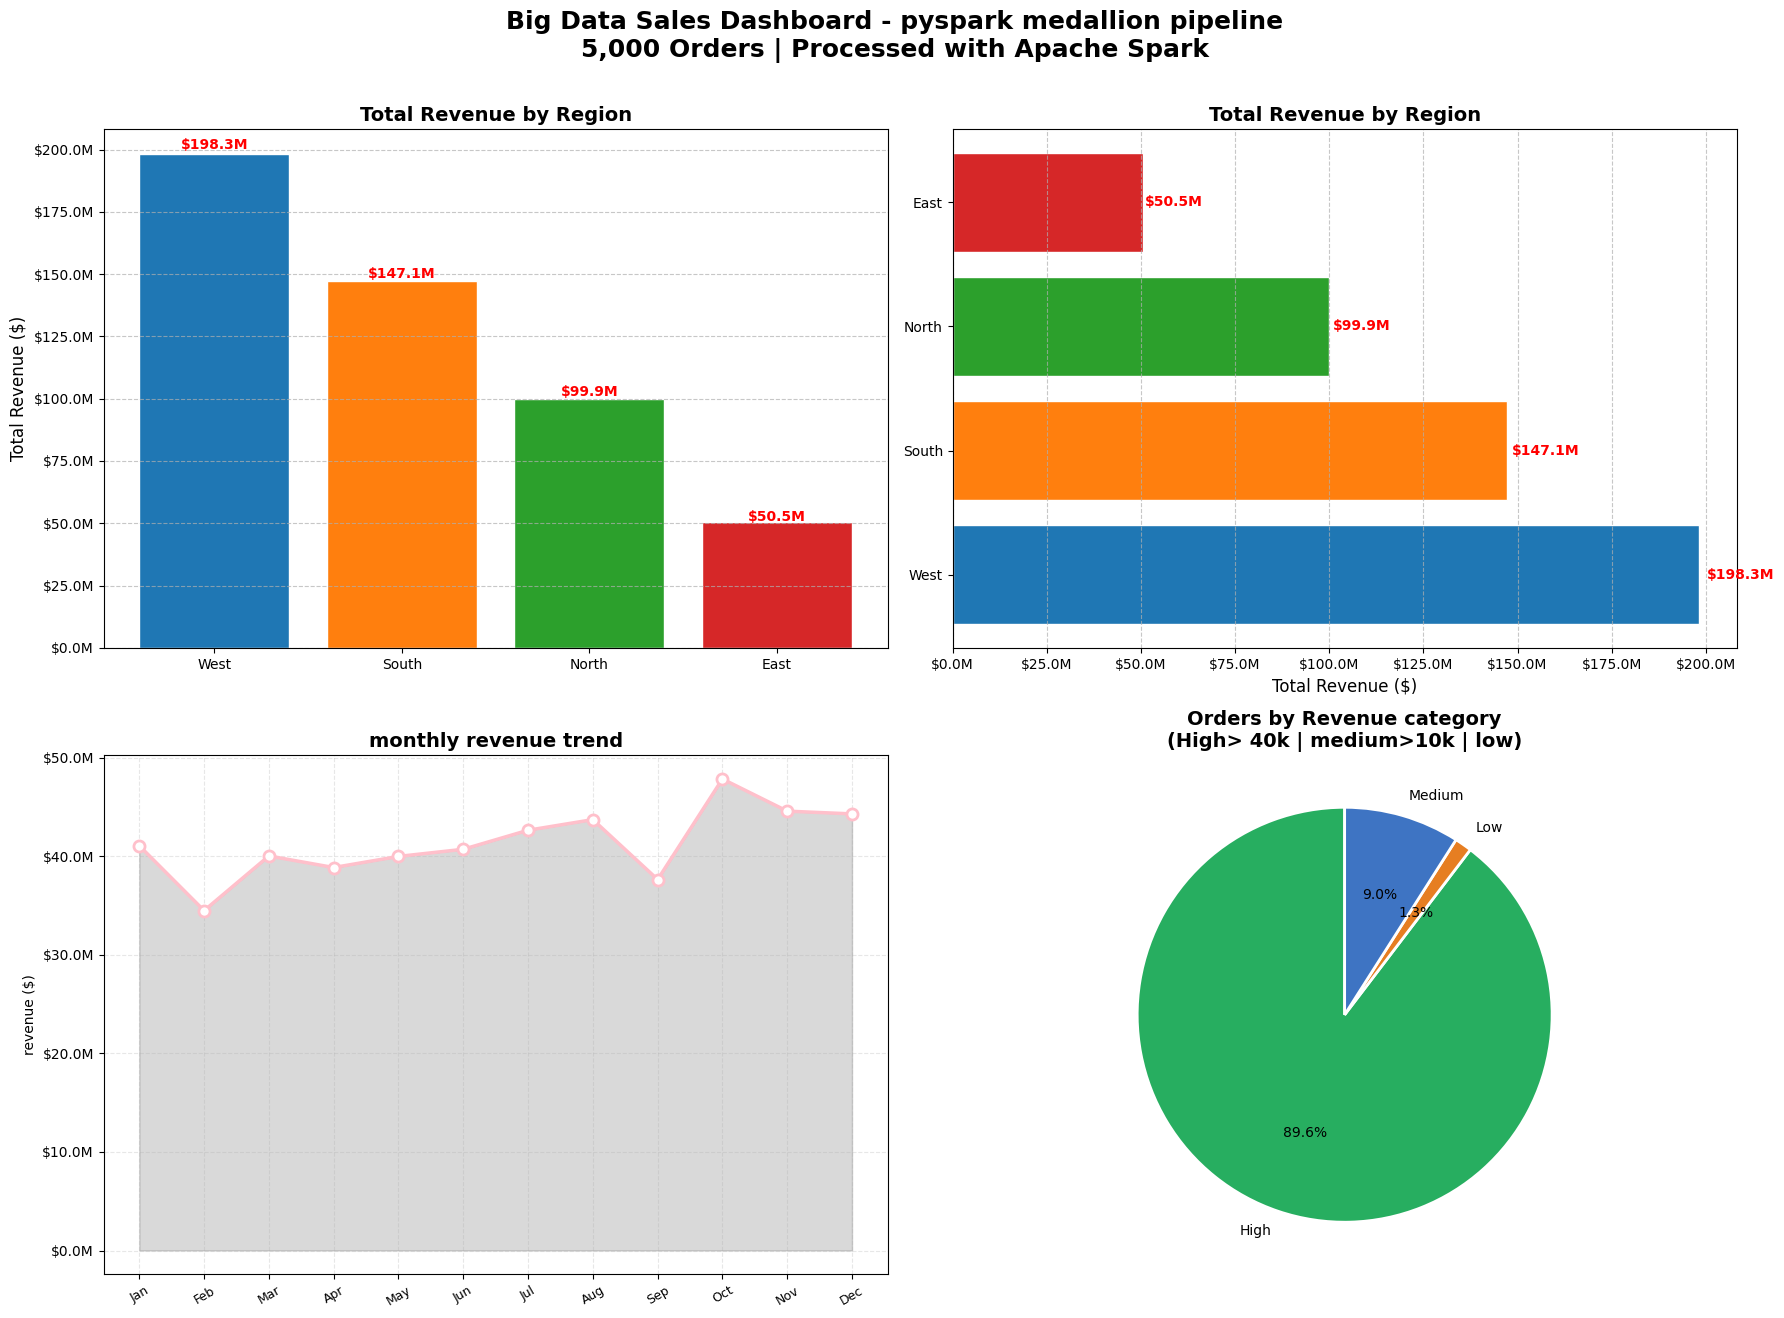

Dashboard saved:big_data_dashboard.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    'Big Data Sales Dashboard - pyspark medallion pipeline\n'
    '5,000 Orders | Processed with Apache Spark',
    fontsize=18, fontweight='bold', color='black' ,y=1.01
)
colors4 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax1 = axes[0][0]
bars1 = ax1.bar(region_pd['region'], region_pd['total_revenue'],
                color=colors4[:len(region_pd)], edgecolor='white')
for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
           f'${bar.get_height()/1e6:.1f}M',
           ha='center', fontsize=10, fontweight='bold', color='red')
ax1.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:  f'${x/1e6:.1f}M'))
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax2 = axes[0][1]
bars2 = ax2.barh(region_pd['region'], region_pd['total_revenue'],
                color=colors4[:len(region_pd)], edgecolor='white')
for barh in bars2:
  ax2.text(barh.get_width() * 1.01,
           barh.get_y() + barh.get_height()/2,
           f'${barh.get_width()/1e6:.1f}M',
           ha='left', va='center', fontsize=10, fontweight='bold', color='red')
ax2.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Revenue ($)', fontsize=12)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:  f'${x/1e6:.1f}M'))
ax2.grid(axis='x', linestyle='--', alpha=0.7)
ax3= axes [1][0]
month_names=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels = [month_names[m-1] for m in monthly_pd['order_month']]
ax3.plot(monthly_labels, monthly_pd['total_revenue'],
         marker='o', linewidth=2.5,color='pink',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax3.fill_between(range(len(monthly_labels)),monthly_pd['total_revenue'],alpha=0.15, color='black'
)
ax3.set_title('monthly revenue trend', fontsize=14, fontweight='bold')
ax3.set_ylabel('revenue ($)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:  f'${x/1e6:.1f}M'))
ax3.grid(alpha=0.3,linestyle='--')
ax3.tick_params(axis='x', rotation=30,labelsize=9)

ax4 = axes[1][1]
rev_cat = df_silver.groupBy('revenue_category') \
    .count().orderBy('revenue_category').toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=['#27AE60','#E67E22','#3E74C3'],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Orders by Revenue category\n(High> 40k | medium>10k | low)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('big_data_dashboard.png',dpi = 150,bbox_inches='tight')
plt.show()
print('Dashboard saved:big_data_dashboard.png')
